# Introducción a los algoritmos de aprendizaje no supervisado

## 1. Introducción al machine learning no supervisado

El aprendizaje no supervisado es una rama del machine learning que se enfoca en encontrar patrones y estructuras ocultas en datos no etiquetados. A diferencia del aprendizaje supervisado, donde los modelos se entrenan con datos que tienen etiquetas o respuestas conocidas, en el aprendizaje no supervisado los algoritmos deben identificar relaciones y agrupaciones por sí mismos.

### Definición del problema y análisis de datos

La interpretración de los datos en aprendizaje no supervisado es crucial, ya que la ausencia de etiquetas hace que la comprensión de las características y la estructura de los datos sea fundamental para el éxito del modelado. Además en ocasiones podemos obtener clusters que no tienen sentido o no son útiles, por lo que es importante entender bien los datos. Unos resultados óptimos dependen de el algoritmo utilizado, los hiperparámetros y la calidad de los datos.

In [1154]:
import pandas as pd
import numpy as np
from skimpy import skim
import sidetable

pd.options.mode.chained_assignment = None  # default='warn'
RNG = 42

We are using the [wine dataset](https://www.kaggle.com/datasets/elvinrustam/wine-dataset) which contains information about different types of wines around the world and their characteristics.

> Our goal is to create a wine recommender based on clustering. We don't have any categorized wines, so we will use unsupervised learning techniques to group similar wines and recommend wines to users based on their preferences.

Features:

- Title: The name or title of the wine.
- Description: A brief textual description providing additional details about the wine.
- Price: The cost of the wine.
- Capacity: The volume or size of the wine bottle.
- Grape: The primary grape variety used in making the wine.
- Secondary Grape Varieties: Additional grape varieties used in the wine blend.
- Closure: The type of closure used for the bottle.
- Country: The country where the wine is produced.
- Unit:
- Characteristics: The "Characteristics" feature encapsulates the unique and discernible flavors and aromas present in a particular wine.
- Per bottle / case / each: The quantity of wine included per unit (bottle, case, or each) sold.
- Type: The general category of the wine.
- ABV: The percentage of alcohol content in the wine.
- Region: The geographic region where the grapes used to make the wine are grown.
- Style: This feature describes the overall sensory experience and characteristics of the wine.
- Vintage: The year the grapes used to make the wine were harvested.
- Appellation: A legally defined and protected geographical indication used to identify where the grapes for a wine were grown.


> We are not going to use 'Title' and 'Description' features for clustering, as they are textual data and would require natural language processing techniques to extract meaningful information. Instead, we will focus on the numerical and categorical features that directly describe the characteristics of the wines.

In [1155]:
df_wine = pd.read_csv('datasets/WineDataset.csv')

# check duplicates
print(f"Number of duplicate rows: {df_wine.duplicated().sum()}")
# drop duplicates
df_wine.drop_duplicates(subset=['Title'], keep='first', inplace=True)

df_wine.drop(columns=['Title', 'Description'], inplace=True)
skim(df_wine)

Number of duplicate rows: 0


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1289   │ │ string      │ 14    │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA  ┃ NA %                    ┃ mean    ┃ sd      ┃ p0  ┃ p25  ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ Unit     │   9 │      0.6982156710628394 │   10.18 │   2.319 │   0 │  9.4 │  10.1 │  10.5 │    39 │    █   │  │
│ └──────────┴─────┴─────────────────────────┴─────────┴─────────┴─────┴──────┴───────┴───────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃          ┃     ┃           ┃          ┃           ┃          ┃           ┃ chars    ┃ words per ┃ total    ┃  │
│ ┃ column   ┃ NA  ┃ NA %      ┃ shortest ┃ longest   ┃ min      ┃ max       ┃ per row  ┃ row       ┃ words    ┃  │
│ ┡━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩  │
│ │ Price    │   0 │         0 │ £26.99   │ £300.00   │ £10.99   │ £99.99    │     16.9 │         3 │     3862 │  │
│ │          │     │           │ each     │ per       │ per      │ per       │          │           │          │  │
│ │          │     │           │          │ bottle    │ bottle   │ bottle    │          │           │          │  │
│ │ Capacity │   0 │         0 │ Our      │ 1.5LTR    │ 1.5LTR   │ Our       │     4.09 │         1 │     1289 │  │
│ │ Grape    │  15 │ 1.1636927 │ Pais     │ Lambrusco │ Agiorgit │ Zwieigelt │     10.2 │       1.3 │     1709 │  │
│ │          │     │ 851047323 │          │ Grasparos │ iko      │           │          │           │          │  │
│ │          │     │           │          │ sa        │          │           │          │           │          │  │
│ │ Secondar │ 801 │ 62.141194 │ Syrah    │ Chardonna │ Airen    │ Viura,    │     18.7 │      0.93 │     1199 │  │
│ │ y Grape  │     │  72459271 │          │ y,        │          │ Tempranil │          │           │          │  │
│ │ Varietie │     │           │          │ Muscat,   │          │ lo        │          │           │          │  │
│ │ s        │     │           │          │ Riesling, │          │           │          │           │          │  │
│ │          │     │           │          │ Traminer, │          │           │          │           │          │  │
│ │          │     │           │          │ Weißburgu │          │           │          │           │          │  │
│ │          │     │           │          │ nder,     │          │           │          │           │          │  │
│ │          │     │           │          │ Welschrie │          │           │          │           │          │  │
│ │          │     │           │          │ sling,    │ 

Only 'Unit' is numerical, the rest are strings that are numerical and categorical. We will need to preprocess them before applying clustering algorithms. We will handle missing values, encode categorical variables, and scale numerical features as needed.

#### Numerical features

We have several string numerical features that need to be preprocessed before applying clustering algorithms. These features include 'Price', 'Capacity', 'Vintage'(year), and 'ABV' (Alcohol By Volume %).

In [1156]:
df_wine.stb.freq(['Price'])

,Price,count,percent,cumulative_count,cumulative_percent
0,£11.99 per bottle,100,7.757952,100,7.757952
1,£14.99 per bottle,96,7.447634,196,15.205586
2,£9.99 per bottle,90,6.982157,286,22.187742
3,£13.99 per bottle,77,5.973623,363,28.161365
4,£16.99 per bottle,67,5.197828,430,33.359193
...,...,...,...,...,...
123,£13.49 per bottle,1,0.077580,1285,99.689682
124,£13.00 per bottle,1,0.077580,1286,99.767261
125,£120.00 per case,1,0.077580,1287,99.844841
126,£120.00 per bottle,1,0.077580,1288,99.922420


We have price per bottle and price per case, we will use only price per bottle so we can drop the other one or convert case price to bottle price.

In [1157]:
df_wine.stb.freq(['Per bottle / case / each'])

,Per bottle / case / each,count,percent,cumulative_count,cumulative_percent
0,per bottle,1278,99.146625,1278,99.146625
1,per case,6,0.465477,1284,99.612102
2,each,5,0.387898,1289,100.000000


Per case represents less than 1% of the data, so we could drop it, but we will convert it to bottle price for completeness, just in case there is a wine brand that only sells by case.

In [1158]:
df_wine.stb.freq(['Capacity'])

,Capacity,count,percent,cumulative_count,cumulative_percent
0,75CL,1192,92.474787,1192,92.474787
1,37.5CL,23,1.784329,1215,94.259116
2,750ML,18,1.396431,1233,95.655547
3,1.5LTR,18,1.396431,1251,97.051978
4,150CL,11,0.853375,1262,97.905353
5,50CL,8,0.620636,1270,98.525989
6,Our,6,0.465477,1276,98.991466
7,2.25L,4,0.310318,1280,99.301784
8,70CL,3,0.232739,1283,99.534523
9,500ML,3,0.232739,1286,99.767261


We have different capacities, we will standardize them to a common unit for better comparison.

In [1159]:
df_wine.stb.freq(['Vintage'])

,Vintage,count,percent,cumulative_count,cumulative_percent
0,2022,318,24.804992,318,24.804992
1,2021,261,20.358814,579,45.163807
2,2020,194,15.132605,773,60.296412
3,NV,170,13.260530,943,73.556942
4,2019,101,7.878315,1044,81.435257
5,2018,69,5.382215,1113,86.817473
6,2017,45,3.510140,1158,90.327613
7,2016,22,1.716069,1180,92.043682
8,2015,19,1.482059,1199,93.525741
9,2014,17,1.326053,1216,94.851794


For intervals like 2012/2015 we need to decide which one to use.

"NV" represents 13% of the data in Vintage, so we can't drop it. We have to understand what it means in the context of wine.

> In wine, "NV" stands for Non-Vintage, meaning the wine is a blend of grapes from multiple harvest years, rather than a single year, to achieve a consistent "house style" or flavor profile year after year, common in Champagne, sparkling wines, and fortified wines like Port. It's a way for winemakers to balance quality and create a signature taste, even in years with poor harvests, by using reserve wines from past vintages. Also referred as 'MV' (Multi-Vintage).

> Vintage: A single year's grapes (usually 85% or more)

In [1160]:
df_wine.stb.freq(['ABV'])

,ABV,count,percent,cumulative_count,cumulative_percent
0,ABV 13.50%,249,19.453125,249,19.453125
1,ABV 13.00%,231,18.046875,480,37.500000
2,ABV 14.00%,188,14.687500,668,52.187500
3,ABV 14.50%,178,13.906250,846,66.093750
4,ABV 12.50%,174,13.593750,1020,79.687500
5,ABV 12.00%,111,8.671875,1131,88.359375
6,ABV 15.00%,45,3.515625,1176,91.875000
7,ABV 11.00%,24,1.875000,1200,93.750000
8,ABV 11.50%,16,1.250000,1216,95.000000
9,ABV 20.00%,13,1.015625,1229,96.015625


We just have to convert them to absolute percentages.

In [1161]:
df_wine.stb.missing()

,missing,total,percent
Secondary Grape Varieties,801,1289,62.141195
Appellation,645,1289,50.038790
Region,166,1289,12.878200
Style,78,1289,6.051202
Characteristics,37,1289,2.870442
Grape,15,1289,1.163693
Closure,11,1289,0.853375
ABV,9,1289,0.698216
Unit,9,1289,0.698216
Vintage,7,1289,0.543057


We will also have to handle missing values in these numerical features, either by imputing them with mean/median values or by removing rows with missing data, depending on the extent of the missingness.

##### Transforming numerical features

We decide to convert 'NV' to NaN and extract the year as float (for ranges we take the first year)

In [1162]:
normalized_vintage = df_wine['Vintage'].replace('NV', np.nan).astype(str).str.extract(r'(\d{4})').astype(float)
df_wine['Vintage'] = normalized_vintage
df_wine['Vintage'] = df_wine['Vintage'].fillna(round(df_wine['Vintage'].mean()))
df_wine.stb.freq(['Vintage'])

,Vintage,count,percent,cumulative_count,cumulative_percent
0,2020.0,376,29.169899,376,29.169899
1,2022.0,318,24.670287,694,53.840186
2,2021.0,265,20.558573,959,74.398759
3,2019.0,102,7.913111,1061,82.311870
4,2018.0,69,5.352987,1130,87.664856
5,2017.0,45,3.491078,1175,91.155935
6,2016.0,23,1.784329,1198,92.940264
7,2015.0,19,1.474011,1217,94.414275
8,2014.0,17,1.318852,1234,95.733126
9,2023.0,12,0.930954,1246,96.664081


In [1163]:
import re

def normalize_wine_price(row):
    price = row['Price']
    price = re.search(r'[\d\.]+', price).group(0)
    price = float(price)
    unit = row['Per bottle / case / each']
    if unit == 'case':
        price /= 12
    return price

df_wine['Price'] = df_wine.apply(normalize_wine_price, axis=1)
print(f"Missing values in 'Price': {df_wine['Price'].isna().sum()}")
df_wine.stb.freq(['Price'])

Missing values in 'Price': 0


,Price,count,percent,cumulative_count,cumulative_percent
0,11.99,100,7.757952,100,7.757952
1,14.99,96,7.447634,196,15.205586
2,9.99,90,6.982157,286,22.187742
3,13.99,77,5.973623,363,28.161365
4,16.99,67,5.197828,430,33.359193
...,...,...,...,...,...
119,33.00,1,0.077580,1285,99.689682
120,20.00,1,0.077580,1286,99.767261
121,13.49,1,0.077580,1287,99.844841
122,13.00,1,0.077580,1288,99.922420


In [1164]:
def ABV_to_absolute_percentage(row):
    if pd.isna(row['ABV']):
        return np.nan
    abv_str = row['ABV']
    abv_str = re.search(r'[\d\.]+', abv_str).group(0)
    return float(abv_str) / 100

df_wine['ABV'] = df_wine.apply(ABV_to_absolute_percentage, axis=1)
df_wine = df_wine.dropna(subset=['ABV'])
df_wine.stb.freq(['ABV'])

,ABV,count,percent,cumulative_count,cumulative_percent
0,0.135,249,19.453125,249,19.453125
1,0.130,231,18.046875,480,37.500000
2,0.140,188,14.687500,668,52.187500
3,0.145,178,13.906250,846,66.093750
4,0.125,174,13.593750,1020,79.687500
5,0.120,111,8.671875,1131,88.359375
6,0.150,45,3.515625,1176,91.875000
7,0.110,24,1.875000,1200,93.750000
8,0.115,16,1.250000,1216,95.000000
9,0.200,13,1.015625,1229,96.015625


In [1165]:
def normalize_wine_capacity_cl(row):
    capacity_str = row['Capacity']
    capacity_str = capacity_str.lower()

    if 'our' in capacity_str:
        return np.nan
    
    capacity = re.search(r'[\d\.]+', capacity_str).group(0)
    capacity = float(capacity)

    if 'cl' in capacity_str:
        capacity = capacity * 1
    elif 'ml' in capacity_str:
        capacity = capacity / 10
    elif 'l' in capacity_str:
        capacity = capacity * 100

    return int(capacity)

df_wine['Capacity'] = df_wine.apply(normalize_wine_capacity_cl, axis=1)
df_wine['Capacity'] = df_wine['Capacity'].fillna(df_wine['Capacity'].mode()[0])
df_wine.stb.freq(['Capacity'])

,Capacity,count,percent,cumulative_count,cumulative_percent
0,75,1207,94.296875,1207,94.296875
1,150,29,2.265625,1236,96.562500
2,37,24,1.875000,1260,98.437500
3,50,11,0.859375,1271,99.296875
4,225,4,0.312500,1275,99.609375
5,70,3,0.234375,1278,99.843750
6,500,1,0.078125,1279,99.921875
7,300,1,0.078125,1280,100.000000


In [1166]:
df_wine.drop(columns=['Per bottle / case / each', 'Unit'], inplace=True)
df_wine.stb.missing()

,missing,total,percent
Secondary Grape Varieties,794,1280,62.031250
Appellation,636,1280,49.687500
Region,157,1280,12.265625
Style,72,1280,5.625000
Characteristics,31,1280,2.421875
Grape,9,1280,0.703125
Type,5,1280,0.390625
Closure,5,1280,0.390625
Price,0,1280,0.000000
Capacity,0,1280,0.000000


In [1167]:
df_wine.head()

,Price,Capacity,Grape,Secondary Grape Varieties,Closure,Country,Characteristics,Type,ABV,Region,Style,Vintage,Appellation
0,9.99,75,Tempranillo,NaN,Natural Cork,Spain,"Vanilla, Blackberry, Blackcurrant",Red,0.140,NaN,Rich & Juicy,2020.0,NaN
1,15.99,75,Chardonnay,NaN,Natural Cork,USA,"Vanilla, Almond, Coconut, Green Apple, Peach, ...",White,0.135,California,Rich & Toasty,2021.0,Napa Valley
2,12.49,75,Sauvignon Blanc,NaN,Screwcap,New Zealand,"Tropical Fruit, Gooseberry, Grapefruit, Grass,...",White,0.130,Marlborough,Crisp & Zesty,2022.0,NaN
3,17.99,75,Chardonnay,NaN,Natural Cork,France,"Peach, Apricot, Floral, Lemon",White,0.135,Burgundy,Ripe & Rounded,2022.0,Macon
4,15.99,75,Pinot Noir,NaN,Natural Cork,USA,"Smoke, Black Cherry, Cedar, Raspberry, Red Fruit",Red,0.135,California,Smooth & Mellow,2021.0,Napa Valley


### Categorical features

There are two features related with grape: 'Grape' and 'Secondary Grape Varieties'.

In [1168]:
df_wine[['Grape', 'Secondary Grape Varieties']].stb.missing()

,missing,total,percent
Secondary Grape Varieties,794,1280,62.031250
Grape,9,1280,0.703125


- 62% of the data is missing in 'Secondary Grape Varieties', so we will drop that feature as it doesn't provide much useful information.
- 'Grape' has 7% of missing data, we will keep it and impute the missing values as 'Unknown'.
> If we were in a production scenario, we could consider reaching out the client to obtain the missing information or understand why it is missing.

In [1169]:
df_wine.drop(columns=['Secondary Grape Varieties'], inplace=True)
df_wine['Grape'] = df_wine['Grape'].fillna('Unknown')
df_wine['Grape'] = df_wine['Grape'].astype('category')

Let's see the remaining missing values in the other categorical features.

In [1170]:
df_wine[['Country', 'Region', 'Type', 'Closure', 'Appellation']].stb.missing()

,missing,total,percent
Appellation,636,1280,49.687500
Region,157,1280,12.265625
Type,5,1280,0.390625
Closure,5,1280,0.390625
Country,0,1280,0.000000


We don't know if Appellation is missing due to not being applicable or not provided. We will drop this feature as there is not enough information to impute it properly.

In [1171]:
df_wine.drop(columns=['Appellation'], inplace=True)

> Region and Type have some missing values, we will impute them as 'Unknown'.

> Closure can be imputed with the mode, as it is likely that most wines use the same type of closure (e.g., cork).

In [1172]:
df_wine[['Closure']].value_counts()

Closure       
Natural Cork      830
Screwcap          414
Synthetic Cork     24
Vinolok             7
Name: count, dtype: int64

In [1173]:
df_wine['Region'] = df_wine['Region'].fillna('Unknown')
df_wine['Region'] = df_wine['Region'].astype('category')
df_wine['Type'] = df_wine['Type'].fillna('Unknown')
df_wine['Type'] = df_wine['Type'].astype('category')
df_wine['Closure'] = df_wine['Closure'].fillna(df_wine['Closure'].mode()[0])
df_wine['Closure'] = df_wine['Closure'].astype('category')

In [1174]:
df_wine.stb.missing()

,missing,total,percent
Style,72,1280,5.625000
Characteristics,31,1280,2.421875
Price,0,1280,0.000000
Grape,0,1280,0.000000
Capacity,0,1280,0.000000
Country,0,1280,0.000000
Closure,0,1280,0.000000
Type,0,1280,0.000000
ABV,0,1280,0.000000
Region,0,1280,0.000000


#### Multicategorical features

We could create dummies for Characteristics and Style, but they have too many unique values, it would increase dimensionality too much. And these characteristics are subjective, for now we will create a new dataset with the expanded features and see if it improves clustering results.

In [1175]:
df_wine_extended = df_wine.copy()
characteristics_dummies = df_wine_extended['Characteristics'].str.get_dummies(sep=',')
style_dummies = df_wine_extended['Style'].str.get_dummies(sep='&')
df_wine_extended = pd.concat([df_wine_extended, characteristics_dummies, style_dummies], axis=1)
df_wine_extended.drop(columns=['Characteristics', 'Style'], inplace=True)

print(f'df_wine_extended num of missing values: {sum(df_wine_extended.isna().sum())}')
print(f'Final size: {df_wine_extended.shape}')
print(f'df_wine num of missing values: {sum(df_wine.isna().sum())}')
print(f'Final size: {df_wine.shape}')

df_wine_extended num of missing values: 0
Final size: (1280, 229)
df_wine num of missing values: 103
Final size: (1280, 11)


After adding the dummies, we increased considerably the number of features, from 11 to 229. But we also have more information to cluster the wines.

Now we can try reducing the information.

### Técnicas de clustering (k-means)

K-means is a popular clustering algorithm used in unsupervised learning to partition a dataset into K distinct clusters based on feature similarity. The algorithm works by iteratively assigning data points to the nearest cluster centroid and then updating the centroids based on the assigned points.

> One weakness of k-means is that it requires the number of clusters (K) to be specified in advance, which can be challenging if the optimal number of clusters is not known beforehand. Additionally, k-means assumes that clusters are spherical and equally sized, which may not always hold true in real-world data.

> Another weakness is that k-means is sensitive to the initial placement of centroids, which can lead to different clustering results on different runs. To mitigate this, multiple initializations (n_init) are often used.

We will use the Elbow Method and Silhouette Score to determine the optimal number of clusters (K) for our dataset.

Before applying k-means, we need to convert the categorical features to numerical to be able to use them in the algorithm.

In [1176]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df_wine_extended['Country'] = df_wine_extended['Country'].astype('category')
X = df_wine_extended.copy()
cat_columns = df_wine_extended.select_dtypes(include=['category']).columns

X[cat_columns] = X[cat_columns].apply(lambda col: col.cat.codes)
X.head()

,Price,Capacity,Grape,Closure,Country,Type,ABV,Region,Vintage,Almond,...,Bold,Crisp,Delicate,Fresh,Light,Rich,Ripe,Savoury,Smooth,Soft
0,9.99,75,93,0,22,2,0.140,84,2020.0,0,...,0,0,0,0,0,1,0,0,0,0
1,15.99,75,16,0,23,6,0.135,13,2021.0,1,...,0,0,0,0,0,1,0,0,0,0
2,12.49,75,86,1,15,6,0.130,49,2022.0,0,...,0,1,0,0,0,0,0,0,0,0
3,17.99,75,16,0,6,6,0.135,12,2022.0,0,...,0,0,0,0,0,0,1,0,0,0
4,15.99,75,75,0,23,2,0.135,13,2021.0,0,...,0,0,0,0,0,0,0,0,1,0


> cat.codes works on pandas Categorical columns. Each unique category is assigned a single integer. Equivalent to Label Encoding in sklearn.

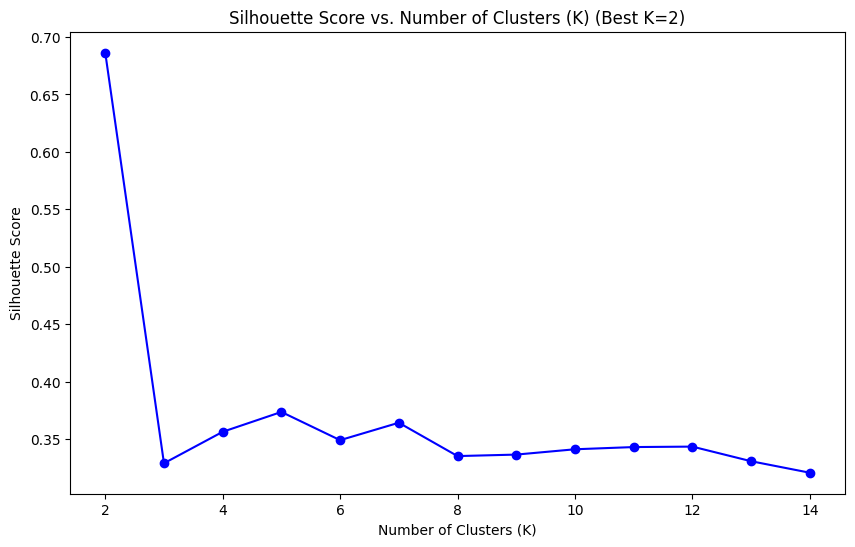

In [1177]:
from matplotlib import pyplot as plt

max_k = 15
kmeans_per_k = [KMeans(n_clusters=k, random_state=RNG).fit(X) for k in range(1, max_k)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

plt.figure(figsize=(10, 6))
# bo- means blue color, circle marker, solid line
plt.plot(range(2, max_k), silhouette_scores, 'bo-')
plt.title(f'Silhouette Score vs. Number of Clusters (K) (Best K={np.argmax(silhouette_scores)+2})')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

The optimal number of clusters (K) with Silhouette Score would be 2, as it has the highest score.

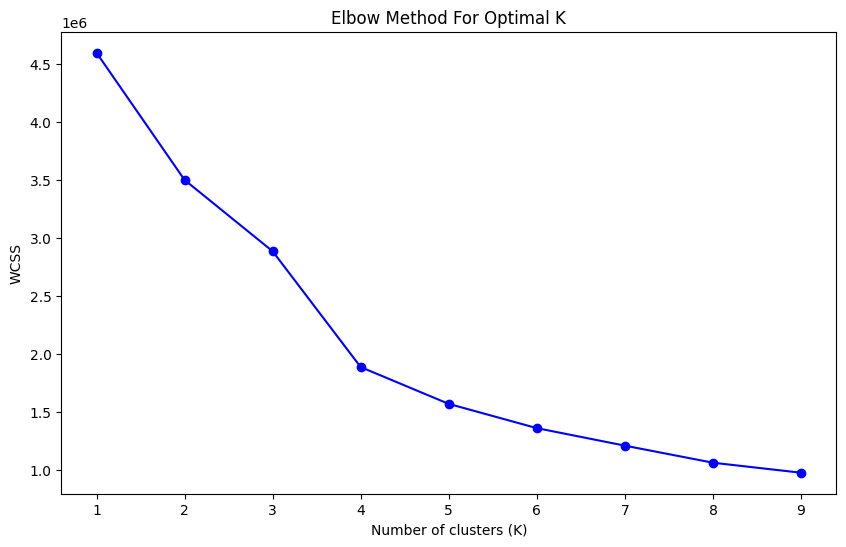

In [1178]:
# wcss means within-cluster sum of squares
wcss = []
max_k = 10
for k in range(1, max_k):
    kmeans = KMeans(n_clusters=k, random_state=RNG)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k), wcss, 'bo-')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

It's called "Elbow Method" because the plot of the inertia values typically resembles an arm, and the "elbow" point indicates the optimal number of clusters where adding more clusters does not significantly improve the model. In this case, the elbow appears to be around 5 clusters, suggesting that this may be a suitable choice for K.

We will take K=5 as the optimal number of clusters for our dataset based on the Elbow Method.

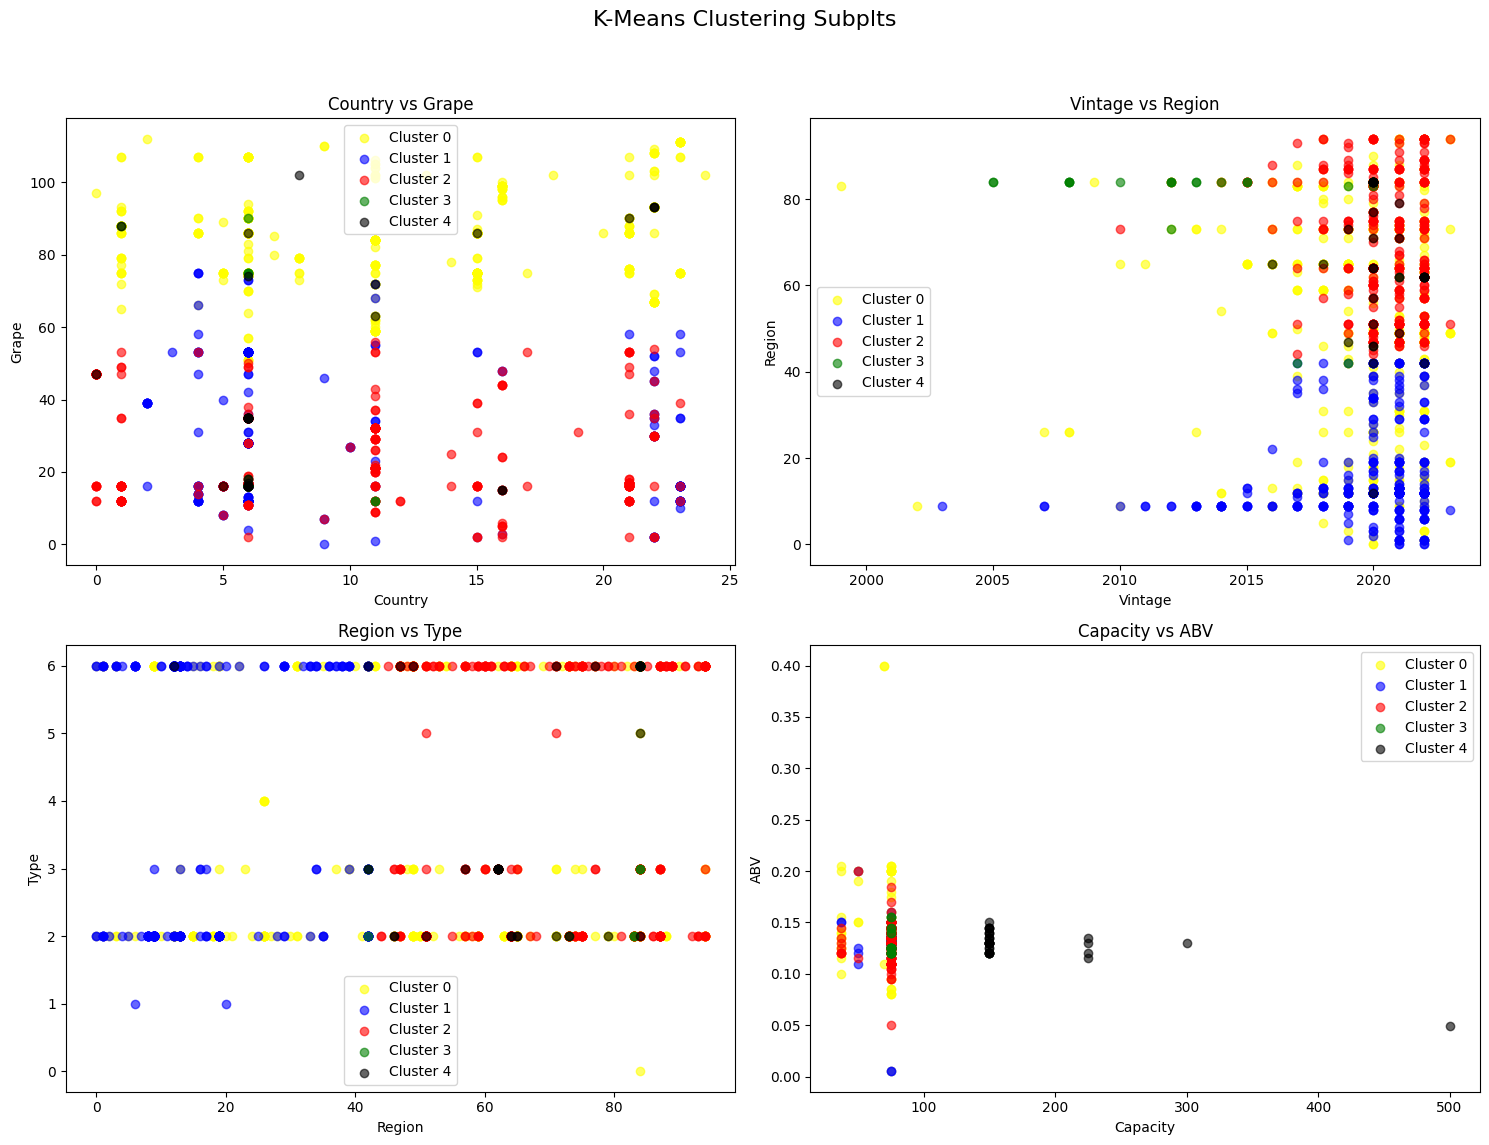

In [1179]:
kmeans = KMeans(n_clusters=5, random_state=RNG)
labels = kmeans.fit_predict(X)

cluster_colors = ['yellow', 'blue', 'red', 'green', 'black']

subplot_configs = [
    ('Country', 'Grape'),
    ('Vintage', 'Region'),
    ('Region', 'Type'),
    ('Capacity', 'ABV'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('K-Means Clustering Subplts', fontsize=16)

for ax, (x_col, y_col) in zip(axes.flatten(), subplot_configs):
    for cluster in range(5):
        cluster_data = X[labels == cluster]
        ax.scatter(cluster_data[x_col], cluster_data[y_col], 
                   color=cluster_colors[cluster], label=f'Cluster {cluster}', alpha=0.6)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # adjust layout to make room for suptitle
plt.show()

### Dimensionality Reduction (PCA)

### Clustering + PCA